Some weights of the model checkpoint at C:\Users\moham\Desktop\checkpoints\checkpoint-120000 were not used when initializing BertModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


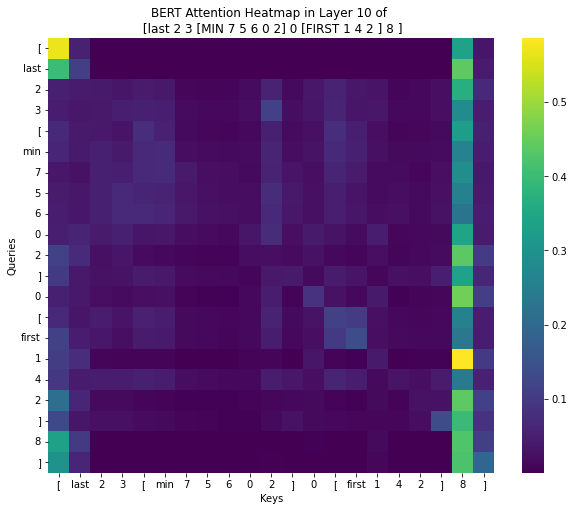

In [21]:
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns

def create_attention_heatmap(model, tokenizer, sequence):
    
    observed_layer= 10
    inputs = tokenizer(sequence, return_tensors="pt", add_special_tokens=True)
    input_ids = inputs["input_ids"]
    tokens = [tokenizer.convert_ids_to_tokens(i) for i in input_ids][0]

    # Obtain attention scores
    with torch.no_grad():
        outputs = model(**inputs)
        attentions = outputs[-1]

    # Average attention scores across all heads
    attention_matrix = torch.mean(attentions[observed_layer][0], dim=0).cpu().numpy()

    # Remove special tokens
    tokens = tokens[1:-1]
    attention_matrix = attention_matrix[1:-1, 1:-1]

    # normalize attention scores
    attention_matrix = attention_matrix / attention_matrix.sum(axis=-1, keepdims=True)

    # Create the heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(attention_matrix, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.xlabel("Keys")
    plt.ylabel("Queries")
    plt.title(f"BERT Attention Heatmap in Layer {observed_layer} of \n {sequence}")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.show()

# Load pre-trained model and tokenizer
model_name = r"C:\Users\moham\Desktop\checkpoints\checkpoint-120000"
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained(model_name, output_attentions=True)

# Input sequence
sequence = "[last 2 3 [MIN 7 5 6 0 2] 0 [FIRST 1 4 2 ] 8 ]"
# Generate and display the attention heatmap
create_attention_heatmap(model, tokenizer, sequence)
